In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Customer-Churn.csv")

values = {"Yes" : 1, "No" : 0}
df["Churn_vals"] = df["Churn"].map(values)


Text(0.5, 1.0, 'Overall Churn Distribution')

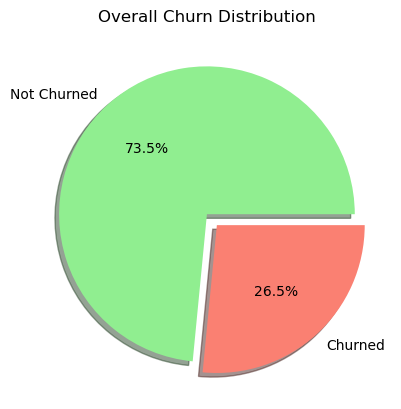

In [3]:
# Overall Churn Distribution

churned_rate = df["Churn_vals"].value_counts()

plt.pie(churned_rate, labels = ["Not Churned", "Churned"], 
        autopct = "%1.1f%%", 
        colors = ["lightgreen", "salmon"],
        shadow = True,
        # wedgeprops = {
        #     "edgecolor" : "black",
        #     "linewidth" : 0.5,
        #     "linestyle" : "-."
        # },
        explode = [0, 0.1]
       )
plt.title("Overall Churn Distribution")

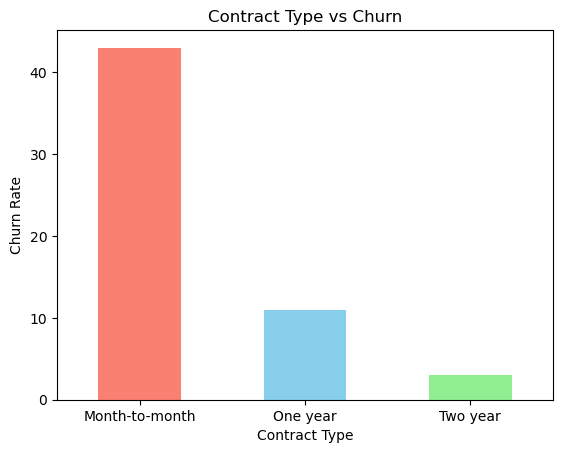

In [4]:
# Contract Type vs Churn

Contract_Wise_Churn = np.round((df.groupby("Contract")["Churn_vals"].mean()) * 100)
Contract_Wise_Churn.plot(kind = "bar", color = ["salmon", "skyblue", "lightgreen"])
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation = 0)
plt.show()

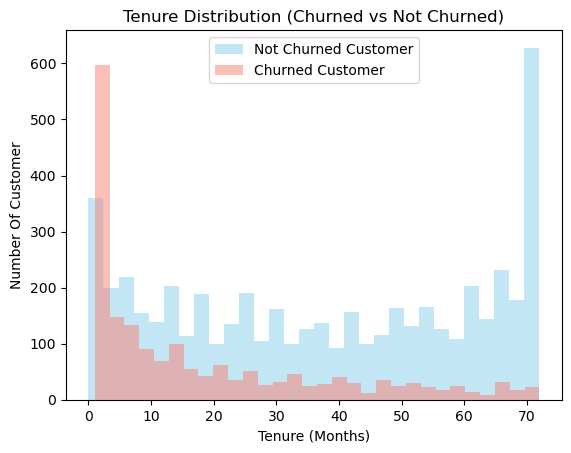

In [5]:
# Tenure Distribution (Churned vs Not Churned)

churned_customer = df[df["Churn_vals"] == 1]
not_churned_customer = df[df["Churn_vals"] == 0]


plt.hist(not_churned_customer["tenure"], bins = 30, alpha = 0.5, color = "skyblue", label = "Not Churned Customer")
plt.hist(churned_customer["tenure"], bins = 30, alpha = 0.5, color = "salmon", label = "Churned Customer")

plt.title("Tenure Distribution (Churned vs Not Churned)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number Of Customer")
plt.legend()
plt.show()

Text(0, 0.5, 'Monthly Charges')

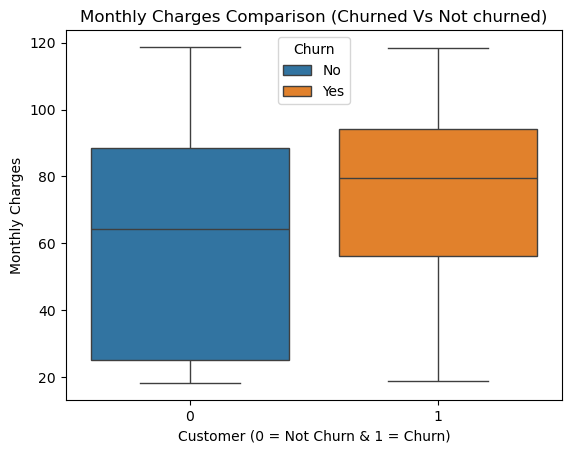

In [6]:
# Monthly Charges Comparison

sns.boxplot(
    data = df,
    x = "Churn_vals",
    y = "MonthlyCharges",
    hue = "Churn"
)
plt.title("Monthly Charges Comparison (Churned Vs Not churned)")
plt.xlabel("Customer (0 = Not Churn & 1 = Churn)")
plt.ylabel("Monthly Charges")
# plt.grid()

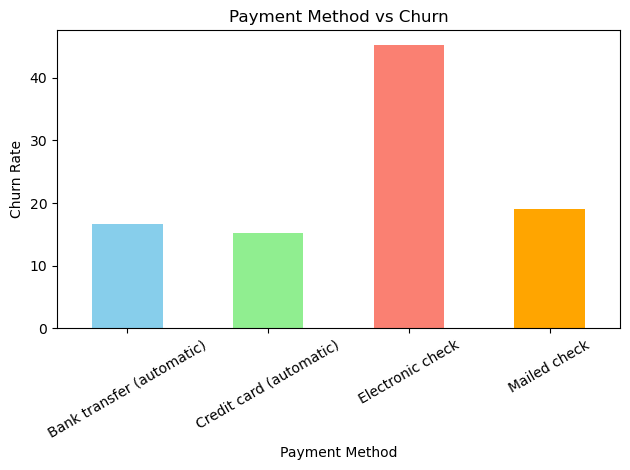

In [7]:
# Payment Method vs Churn

payment_method = (df.groupby("PaymentMethod")["Churn_vals"].mean()) * 100

payment_method.plot(kind = "bar", color = ["skyblue", "lightgreen", "salmon", "orange"])
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

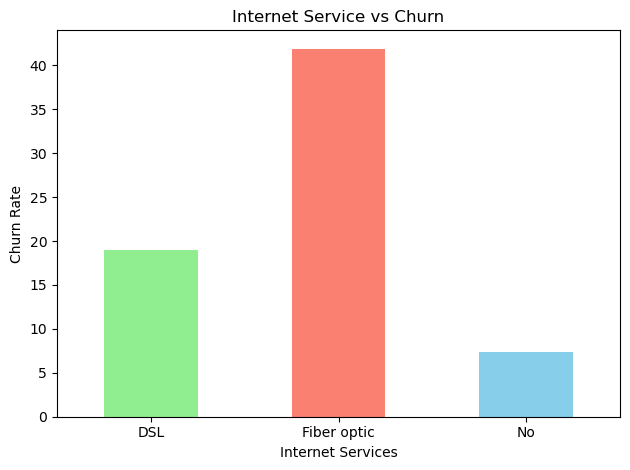

In [8]:
# Internet Service vs Churn

internet_services = (df.groupby("InternetService")["Churn_vals"].mean()) * 100

internet_services.plot(kind = "bar", color = ["lightgreen", "salmon", "skyblue"])
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Services")
plt.ylabel("Churn Rate")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

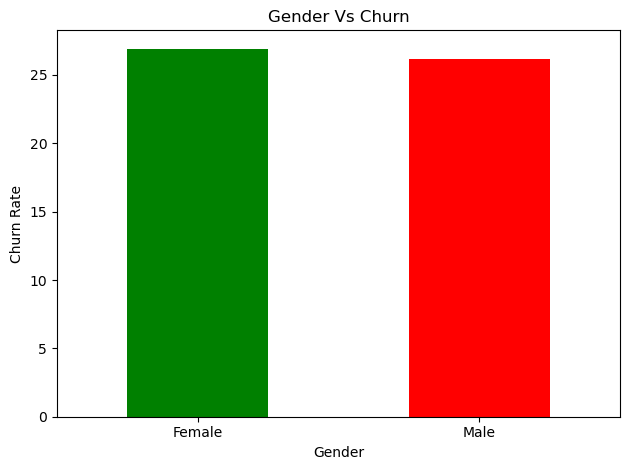

In [9]:
# Gender vs Churn

Gender_churn = (df.groupby("gender")["Churn_vals"].mean()) * 100

Gender_churn.plot(kind = "bar" , color = ["green", "red"])
plt.title("Gender Vs Churn")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

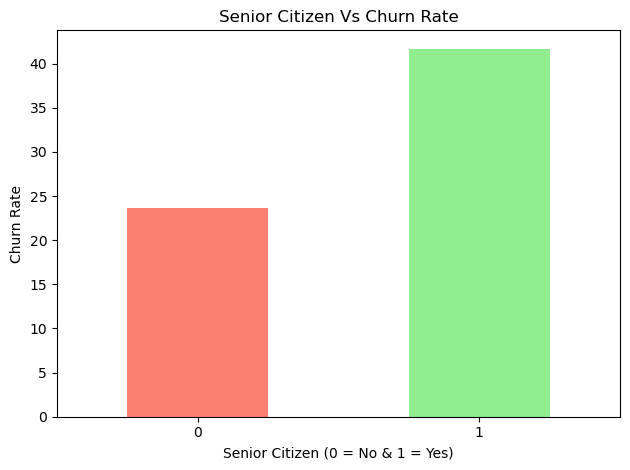

In [10]:
# Senior Citizen vs Churn

Senior_citizen = (df.groupby("SeniorCitizen")["Churn_vals"].mean()) * 100

Senior_citizen.plot(kind = "bar", color = ["salmon", "lightgreen"])
plt.title("Senior Citizen Vs Churn Rate")
plt.xlabel("Senior Citizen (0 = No & 1 = Yes)")
plt.ylabel("Churn Rate")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_4132\1538596167.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors='coerce')


<Axes: >

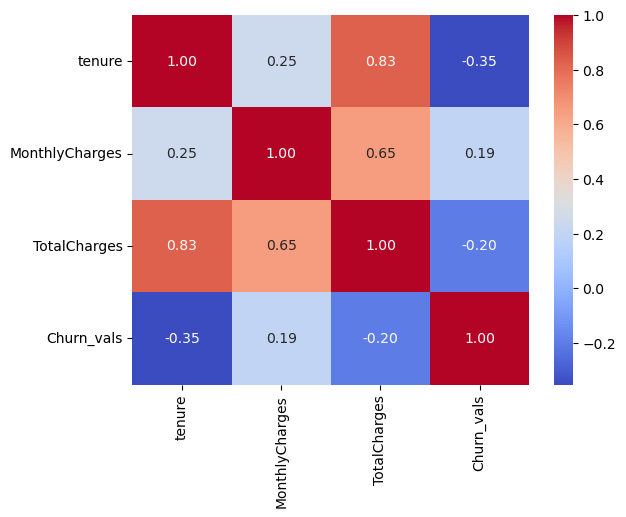

In [11]:
# Correlation Heatmap

# df_pivot = df.pivot_table(index = "Churn_vals", columns = "tenure", values = "MonthlyCharges")
# df_pivot
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_vals']]
numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors='coerce')

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)

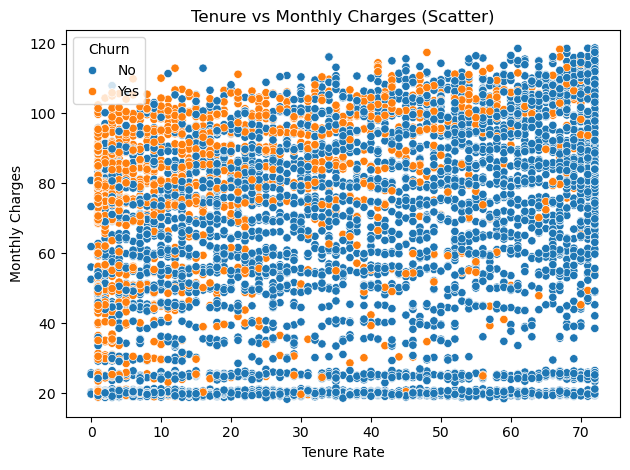

In [12]:
# Tenure vs Monthly Charges (Scatter)

sns.scatterplot(
    data = df,
    x = "tenure",
    y = "MonthlyCharges",
    hue = "Churn"
)
plt.title("Tenure vs Monthly Charges (Scatter)")
plt.xlabel("Tenure Rate")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_vals
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
